In [16]:
from scripts.getQuartets import *
import numpy as np
from matplotlib import pyplot as plt

In [17]:
FACTORS = ["0.5", "1.0", "2.0", "4.0", "8.0"]
POLYMORPHISM = ["modhigh", "veryhigh", "mod", "high", "low"]
METHODS = ["ASTRAL", "PAUP"]

In [18]:
def get_data(score_path="./inference_outputs/scores.txt", method=None, has_morph: str = ""):
    data = {'score': [], 'polymorphism': [], 'factor': [], 'method': [], 'has_morph': []}
    with open(score_path) as f:
        lines = f.read().split('\n')
        N = len(lines)
        for i in range(0, N - 1, 2):
            filename = lines[i]
            score = float(lines[i + 1].split()[1])        
            if(score < 0):
                print("Negative value: ", filename)
                continue
            data['score'].append(score * 100)
            for p in POLYMORPHISM:
                if p in filename:
                    data['polymorphism'].append(p)
                    break
            for f in FACTORS:
                if f in filename:
                    data['factor'].append(f)
                    break
            data['method'].append(method)
            data['has_morph'].append(has_morph)
            # print(s, score)
    return data


In [21]:

data = {
    'score': [],
    'polymorphism': [],
    'method': [],
    'factor': [],
    'summary': [],
    'has_morph': []
}
factors = ["0.5", "1.0", "2.0", "4.0", "8.0"]
methods = ['ASTRAL','MP4']
hue_ord = []
for f in factors:
    for m in methods:
        data_ = get_data(f"/Users/liusean/Desktop/Projects/Coding/Phylo/QuartetMethods/inference_outputs-{f}/{m}/allscores.txt", m, has_morph='No morphological chrs.')
        data['score'] += data_['score']
        data['polymorphism'] += data_['polymorphism']
        data['method'] += [ m for m in data_['method'] ]
        data['factor'] += data_['factor']
        data['has_morph'] += data_['has_morph']
        data['summary'] += [f'{m}-{p}' for m, p in zip(data_['method'], data_['polymorphism'])]

for p in ["low", "mod", "modhigh", "high", "veryhigh"]:
    for m in METHODS:
        hue_ord.append(f'{m}-{p}')

data_nomorph = data

Negative value:  ./QuartetMethods/example/simulated_data_small-8.0/mod_noborrowing/no-morph/sim_tree32_4.csv


In [22]:
import seaborn as sns

In [23]:

data = {
    'score': [],
    'polymorphism': [],
    'method': [],
    'factor': [],
    'summary': [],
    'has_morph': []
}
factors = ["0.5", "1.0", "2.0", "4.0", "8.0"]
factors = ["0.5"]
methods = {'ASTRAL', 'MP4'}
hue_ord = []
for f in factors:
    for m in methods:
        data_ = get_data(f"/Users/liusean/Desktop/Projects/Coding/Phylo/QuartetMethods/outputs_with_morphology/inference_outputs-{f}/{m}/allscores.txt", m, has_morph="With morphological chars.")
        data['score'] += data_['score']
        data['polymorphism'] += data_['polymorphism']
        data['method'] += data_['method']
        data['factor'] += data_['factor']
        data['has_morph'] += data_['has_morph']
        data['summary'] += [f'{m}-{p}' for m, p in zip(data_['method'], data_['polymorphism'])]

for p in ["low", "mod", "modhigh", "high", "veryhigh"]:
    for m in METHODS:
        hue_ord.append(f'{m}-{p}')

data_morph = data

In [24]:
def merge_datas(A, B):
    for x, t in A.items():
        B[x] += t
        print(x)
    return B

In [29]:
data = merge_datas(data_morph, data_nomorph)
df = pd.DataFrame(data)
df_morph = pd.DataFrame(data_morph)
df_nomorph = pd.DataFrame(data_nomorph)

score
polymorphism
method
factor
summary
has_morph


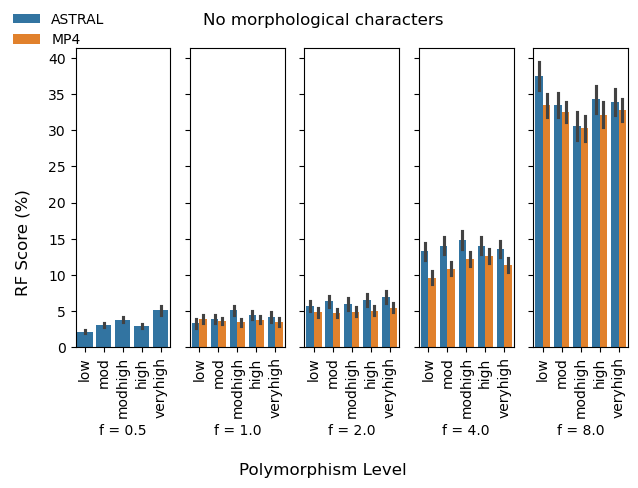

In [30]:
fig, axes = plt.subplots(1, 5, sharey=True)
fig.suptitle("No morphological characters")
fig.supylabel("RF Score (%)")
fig.supxlabel("Polymorphism Level")
loc, labels = plt.xticks()
for f, ax in zip(FACTORS, axes):
    sns.barplot(ax=ax, data=df_nomorph[df_nomorph["factor"] == f], x='polymorphism', y='score', hue='method', errorbar='se')
    ax.get_legend().remove()
    ax.set_xlabel(f"f = {f}")
    ax.set_ylabel("")
    ax.tick_params(axis='x', rotation=90)
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc='upper left', frameon=False)

plt.tight_layout()

AttributeError: 'NoneType' object has no attribute 'remove'

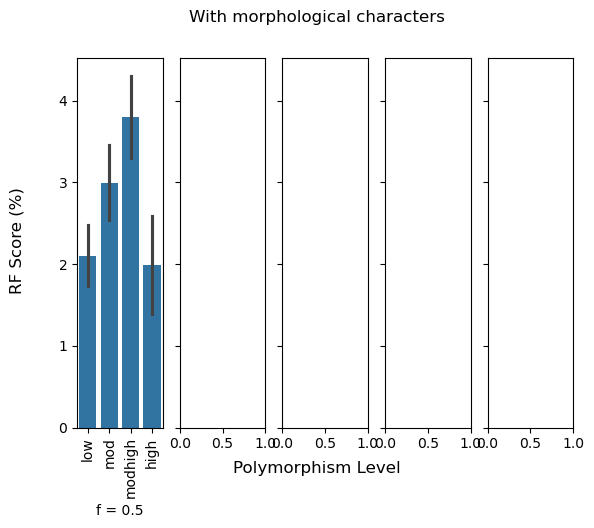

In [31]:
from matplotlib.legend import _get_legend_handles_labels
fig, axes = plt.subplots(1, 5, sharey=True)
fig.suptitle("With morphological characters")
fig.supylabel("RF Score (%)")
fig.supxlabel("Polymorphism Level")
loc, labels = plt.xticks()
for f, ax in zip(FACTORS, axes):
    sns.barplot(ax=ax, data=df_morph[df_morph["factor"] == f], x='polymorphism', y='score', hue='method', errorbar='se')
    ax.get_legend().remove()
    ax.set_xlabel(f"f = {f}")
    ax.set_ylabel("")
    ax.tick_params(axis='x', rotation=90)
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc='upper left', frameon=False)

plt.tight_layout()

In [32]:
no_morph_errors = df_nomorph.groupby(["factor", "method", "polymorphism"])["score"].aggregate("mean")
no_morph_errors_np = np.array(no_morph_errors)

In [33]:
morph_errors = df_morph.groupby(["factor", "method", "polymorphism"])["score"].aggregate("mean")
morph_errors_np = np.array(morph_errors)

In [34]:
morph_advantage = no_morph_errors - morph_errors

In [35]:
morph_advantage

factor  method  polymorphism
0.5     MP4     high            0.968162
                low             0.088046
                mod             0.043403
                modhigh         0.037202
                veryhigh             NaN
1.0     ASTRAL  high                 NaN
                low                  NaN
                mod                  NaN
                modhigh              NaN
                veryhigh             NaN
        MP4     high                 NaN
                low                  NaN
                mod                  NaN
                modhigh              NaN
                veryhigh             NaN
2.0     ASTRAL  high                 NaN
                low                  NaN
                mod                  NaN
                modhigh              NaN
                veryhigh             NaN
        MP4     high                 NaN
                low                  NaN
                mod                  NaN
                modhigh     

In [36]:
df

,score,polymorphism,method,factor,summary,has_morph
0,0.000000,low,MP4,0.5,MP4-low,No morphological chrs.
1,0.000000,low,MP4,0.5,MP4-low,No morphological chrs.
2,7.142857,low,MP4,0.5,MP4-low,No morphological chrs.
3,0.000000,low,MP4,0.5,MP4-low,No morphological chrs.
4,0.000000,low,MP4,0.5,MP4-low,No morphological chrs.
...,...,...,...,...,...,...
6620,0.000000,high,MP4,0.5,MP4-high,With morphological chars.
6621,0.000000,high,MP4,0.5,MP4-high,With morphological chars.
6622,0.000000,high,MP4,0.5,MP4-high,With morphological chars.
6623,7.142857,high,MP4,0.5,MP4-high,With morphological chars.


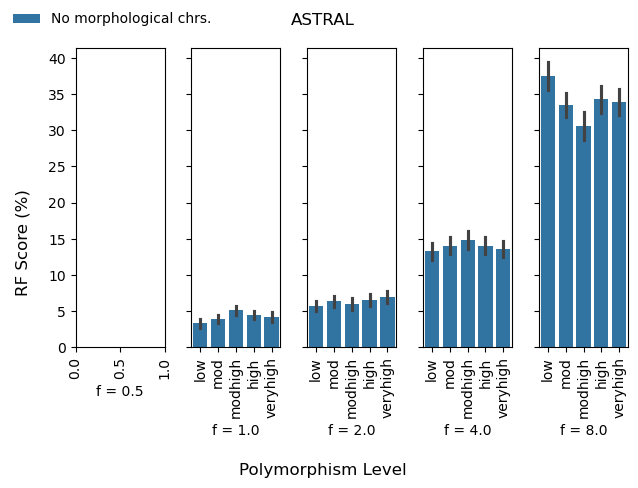

In [37]:
from matplotlib.legend import _get_legend_handles_labels
fig, axes = plt.subplots(1, 5, sharey=True)
fig.suptitle("ASTRAL")
fig.supylabel("RF Score (%)")
loc, labels = plt.xticks()
df_ = df[df["method"] == "ASTRAL"]
for f, ax in zip(FACTORS, axes):
    sns.barplot(ax=ax, data=df_[df_["factor"] == f], x='polymorphism', y='score', hue='has_morph', errorbar='se')
    try:
        ax.get_legend().remove()
    except:
        pass
    ax.set_xlabel(f"f = {f}")
    ax.set_ylabel("")
    ax.tick_params(axis='x', rotation=90)
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc='upper left', frameon=False)

plt.tight_layout()

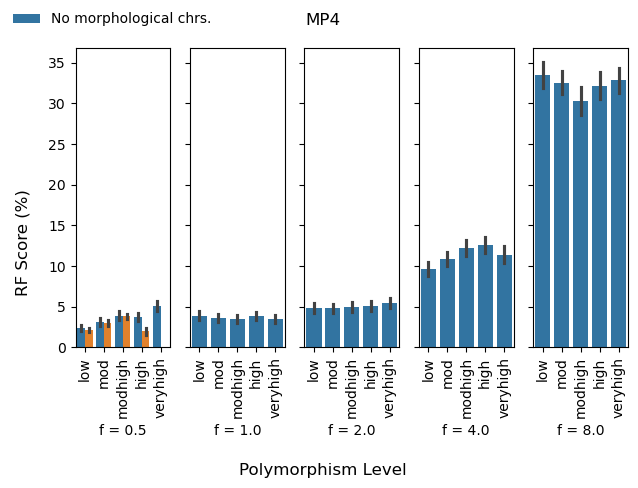

In [38]:
target_method = "MP4"
from matplotlib.legend import _get_legend_handles_labels
fig, axes = plt.subplots(1, 5, sharey=True)

fig.suptitle(target_method)
fig.supylabel("RF Score (%)")
loc, labels = plt.xticks()
df_ = df[df["method"] == target_method]
for f, ax in zip(FACTORS, axes):
    sns.barplot(ax=ax, data=df_[df_["factor"] == f], x='polymorphism', y='score', hue='has_morph', errorbar='se')
    ax.get_legend().remove()
    ax.set_xlabel(f"f = {f}")
    ax.set_ylabel("")
    ax.tick_params(axis='x', rotation=90)
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc='upper left', frameon=False)

plt.tight_layout()